In [58]:
import numpy as np
import pandas as pd

In [79]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)\

# Features
X = diabetes.data

# Target
y = diabetes.target

# Combine into a single DataFrame
df = X.copy()
df['target'] = y
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


# training a linear regression model (can be any model process will be same)

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

test_df=df.iloc[300:,:].drop(columns=['target'])
df=df.iloc[:300,:]
si=SimpleImputer(strategy='mean')
df[df.columns[:-1]]=si.fit_transform(df.values[:,:-1])

model=LinearRegression()
model.fit(df[df.columns[:-1]],df['target'])

LinearRegression()

In [81]:
# base value
new_df=si.transform([[None for i in range(len(df.columns)-1)]])
model.predict(new_df)

C:\Users\panka\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([149.07])

In [106]:
import shap

explainer = shap.Explainer(model,df.iloc[:,:-1])
shap_values = explainer(test_df)
actual_shap_values=explainer.shap_values(test_df)
actual_shap_values

array([[-3.13660038e-01,  9.46723669e+00,  4.24155812e+01, ...,
         2.69525476e-01,  2.92947653e+01,  5.09533586e+00],
       [-1.26427271e-02, -1.48077292e+01, -1.26067693e+01, ...,
         1.93858231e-02, -1.14002622e+01,  4.14912678e+00],
       [-2.53456576e-01,  9.46723669e+00,  2.00438563e+01, ...,
         1.95796813e+00,  2.18862277e+01,  3.20291771e+00],
       ...,
       [-7.35084274e-01, -1.48077292e+01, -7.76963960e+00, ...,
        -1.41891718e+00, -2.75328720e+01,  1.78360410e+00],
       [ 7.09798820e-01,  9.46723669e+00,  2.30670623e+01, ...,
         4.95964396e+00,  3.03275754e+01, -2.94744126e+00],
       [ 7.09798820e-01,  9.46723669e+00, -3.98156240e+01, ...,
        -6.23410549e+00, -5.29791212e-01,  3.64290493e-01]],
      shape=(142, 10))

# Plots

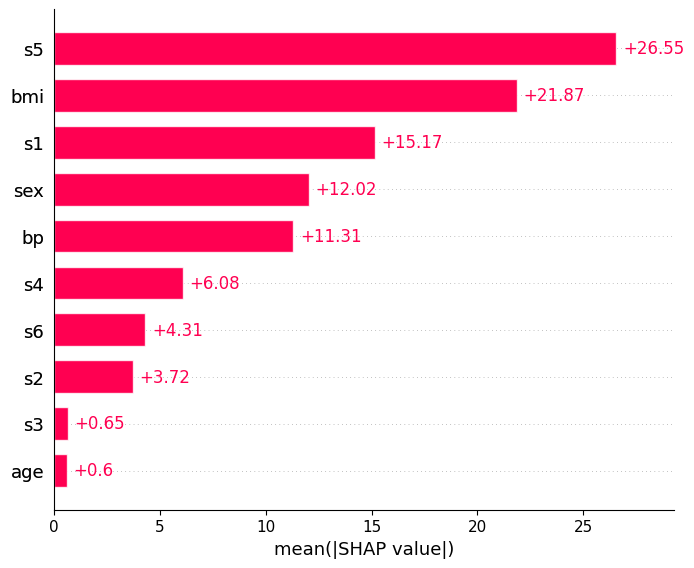

In [ ]:
# What it shows:

# The mean absolute SHAP value for each feature.

# Higher bar = stronger average contribution of that feature to predictions.
# Interpretation:

# If bmi has the largest bar → body mass index is the most influential feature in predicting diabetes progression.

# This is similar to "feature importance," but grounded in Shapley values.

shap.plots.bar(shap_values)

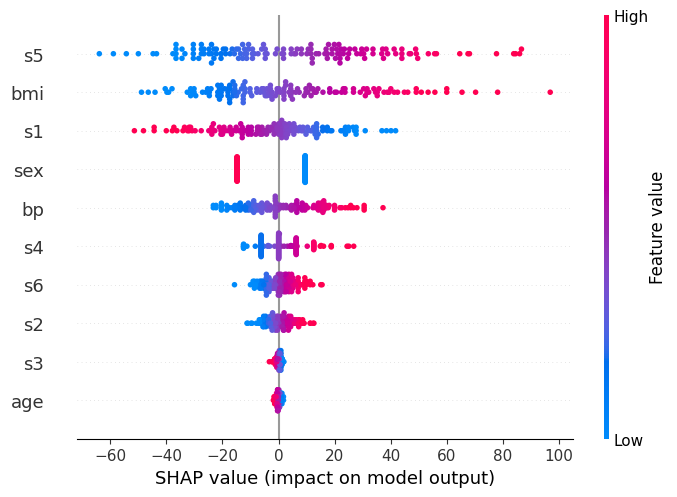

In [93]:
# What it shows:

# Each point = one patient (row in test set).

# X-axis = SHAP value (impact on prediction).

# Color = feature value (blue = low, red = high).

# Features sorted by overall importance (like bar plot).

# Interpretation:

# If high bmi (red points) cluster on the right → high BMI pushes predictions higher (more severe diabetes progression).

# If low bp (blue points) cluster on the left → low blood pressure lowers prediction.

# Lets you see both importance and direction of effect.

shap.plots.beeswarm(shap_values)

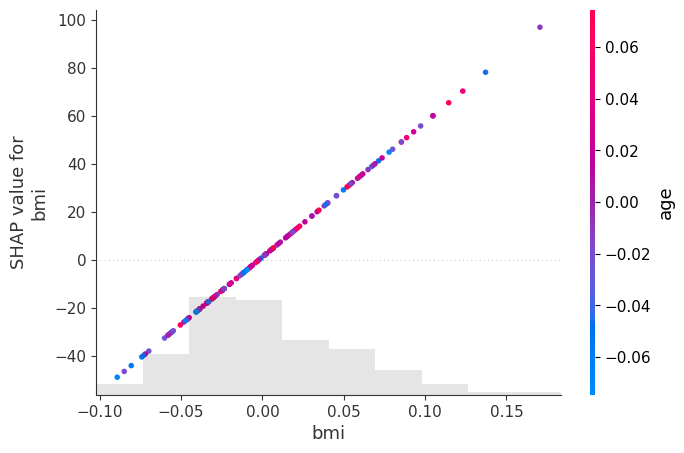

In [95]:
# What it shows:

# Relationship between a single feature’s values (e.g., bmi) and its SHAP values.

# Each point = one patient.

# X-axis = feature value (bmi).

# Y-axis = SHAP value (impact on prediction).

# Color = interaction with another feature (default: the most interacting one).

# Interpretation:

# A clear upward slope means as BMI increases, diabetes progression prediction also increases.

# The spread or non-linearity reveals interactions with other features.
shap.plots.scatter(shap_values[:, "bmi"], color=shap_values)

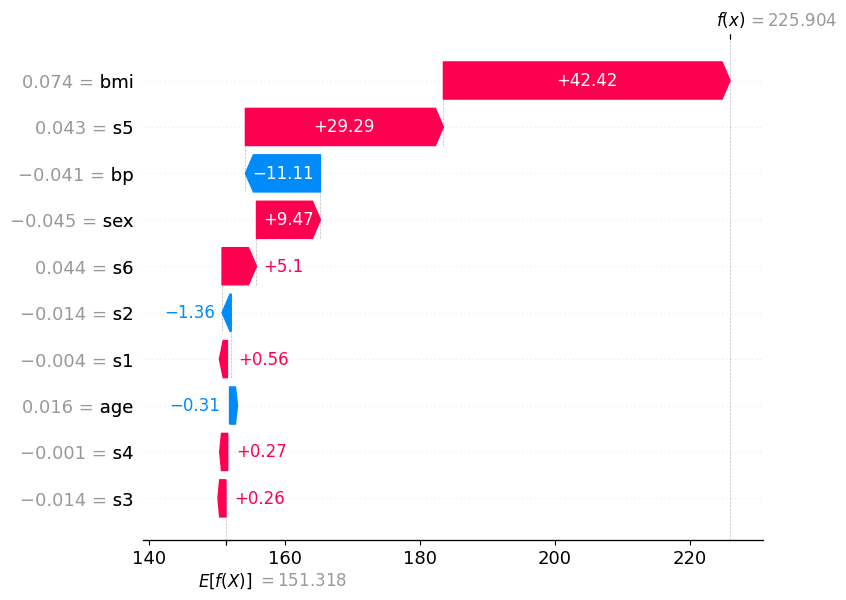

In [104]:
# What it shows:

# Another breakdown of one prediction (like force plot).

# Starts from baseline → adds/subtracts contributions → ends at final prediction.

# Interpretation:

# Lets you read the story step-by-step:

# e.g., "The average predicted diabetes progression is 150. Because of this patient’s high BMI and high blood pressure, prediction increased by +60, but low s2 reduced it by -10, ending at ~200."
shap.plots.waterfall(shap_values[0])

In [105]:
# waterfall plot in one d 
shap.initjs()
shap.plots.force(shap_values[0])